# ML & Forecasting voor Recommender Systems (MongoDB)

## 1. Imports


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from pymongo import MongoClient

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

## 2. Connection to MongoDB

In [2]:
load_dotenv()

MONGODB_URI = os.getenv("MONGODB_URI")
MONGODB_DB = os.getenv("MONGODB_DB")

MONGODB_COLLECTION_INTERACTIONS = os.getenv("MONGODB_COLLECTION_INTERACTIONS", "interactions")
MONGODB_COLLECTION_STEAMAPPS = os.getenv("MONGODB_COLLECTION_STEAMAPPS", "steam_apps")     # Voor game namen
MONGODB_COLLECTION_GAMES = os.getenv("MONGODB_COLLECTION_GAMES", "games")

if not MONGODB_URI or not MONGODB_DB:
    raise ValueError("Zet MONGODB_URI en MONGODB_DB in je .env bestand.")

client = MongoClient(MONGODB_URI)
db = client[MONGODB_DB]


## 3. Data ophalen uit MongoDB

In [3]:
print("Data ophalen uit MongoDB...")

# A. Interactions ophalen (ratings/plays)
ratings_cursor = db[MONGODB_COLLECTION_INTERACTIONS].find({})
ratings = pd.DataFrame(list(ratings_cursor))

# Kolomnamen standaardiseren
ratings = ratings.rename(columns={
    "SteamId": "user_id",
    "AppId": "app_id",
    "PlaytimeForever": "playtime_forever",
    "CreatedUtc": "created_utc",
    "UpdatedUtc": "updated_utc",
})

# Helper: MongoDB $date velden normaliseren
def _mongo_date_to_dt(value):
    if isinstance(value, dict) and "$date" in value:
        return pd.to_datetime(value["$date"], errors="coerce")
    return pd.to_datetime(value, errors="coerce")

if "created_utc" in ratings.columns:
    ratings["created_utc"] = ratings["created_utc"].apply(_mongo_date_to_dt)
if "updated_utc" in ratings.columns:
    ratings["updated_utc"] = ratings["updated_utc"].apply(_mongo_date_to_dt)

# Voor time-based splits gebruiken we bij voorkeur created_utc, anders updated_utc
if "created_utc" in ratings.columns and ratings["created_utc"].notna().any():
    ratings["review_date"] = ratings["created_utc"]
elif "updated_utc" in ratings.columns and ratings["updated_utc"].notna().any():
    ratings["review_date"] = ratings["updated_utc"]

# B. Game metadata ophalen (voor leesbare aanbevelingen)
print("Game metadata ophalen...")
apps_cursor = db[MONGODB_COLLECTION_STEAMAPPS].find({}, {"AppId": 1, "Name": 1, "_id": 0})
apps_df = pd.DataFrame(list(apps_cursor))
# Maak een lookup dictionary: ID -> Naam
id_to_name = {}
if not apps_df.empty:
    id_to_name = apps_df.set_index("AppId")["Name"].to_dict()

# C. Validatie van data
required_fields = {"user_id", "app_id"}
if not required_fields.issubset(set(ratings.columns)):
    raise ValueError(f"Verplichte velden ontbreken: {required_fields - set(ratings.columns)}")

# Impliciete feedback omzetten naar rating (Log transformatie voor playtime)
if "rating" not in ratings.columns:
    if "playtime_forever" in ratings.columns:
        # log1p zorgt dat 0 blijft 0, en vlakt extreme uitschieters af
        ratings["rating"] = np.log1p(ratings["playtime_forever"])
    else:
        raise ValueError("Geen 'rating' of 'playtime_forever' gevonden.")

print(f"Dataset ingeladen: {ratings.shape[0]} rijen.")
print(ratings.head())


Data ophalen uit MongoDB...
Game metadata ophalen...
Dataset ingeladen: 4066 rijen.
                        _id            user_id  app_id  playtime_forever  \
0  000000000000000000000000  76561198164987397     220             182.0   
1  69430a9999ef83246483b402  76561198080219056     220             793.0   
2  69430a9999ef83246483b403  76561198080219056     400             208.0   
3  69430a9999ef83246483b404  76561198080219056     550            1102.0   
4  69430a9999ef83246483b405  76561198080219056     620            1465.0   

   Playtime2Weeks             created_utc             updated_utc  \
0             0.0 2025-12-17 19:42:36.009 2026-01-02 16:51:39.402   
1             0.0                     NaT 2025-12-17 19:55:04.152   
2             0.0                     NaT 2025-12-17 19:55:04.152   
3             0.0                     NaT 2025-12-17 19:55:04.152   
4             0.0                     NaT 2025-12-17 19:55:04.152   

              review_date    rating  
0 2025

In [4]:
# ==========================================
# GAMES METADATA OPHALEN (SAFE VERSION)
# ==========================================

print("Games metadata ophalen...")

MONGODB_COLLECTION_GAMES = "games"  # collectie met game stats

try:
    # 1. Controleer eerst hoeveel games er zijn
    total_games = db[MONGODB_COLLECTION_GAMES].count_documents({})
    print(f"Totaal games in database: {total_games}")
    
    # 2. Laad ALLEEN wat je nodig hebt
    games_cursor = db[MONGODB_COLLECTION_GAMES].find(
        {},
        {
            "AppId": 1,
            "Name": 1,
            "ReleaseYear": 1,
            "UpdatedUtc": 1,
            "ReviewTotal": 1,
            "ReviewScore": 1,
            "_id": 0
        }
    )
    
    # 3. Laad in chunks (niet alles in 1x)
    games_list = []
    for i, doc in enumerate(games_cursor):
        games_list.append(doc)
        if (i + 1) % 10000 == 0:
            print(f"  {i + 1} games geladen...")
    
    games = pd.DataFrame(games_list)
    print(f"✓ {len(games)} games ingeladen")
    
    # 4. Maak lookup dictionary
    if "AppId" in games.columns and "Name" in games.columns:
        id_to_name = dict(zip(games["AppId"], games["Name"]))
        print(f"✓ Lookup table gemaakt: {len(id_to_name)} games")
        
        # Laat een voorbeeld zien
        print("\nVoorbeelden:")
        for app_id, name in list(id_to_name.items())[:5]:
            print(f"  {app_id} → {name}")
    else:
        print(f"✗ Kolommen niet gevonden. Beschikbaar: {games.columns.tolist()}")
        id_to_name = {}

    # 5. Maak release_date op basis van ReleaseYear (jaar-level)
    if "ReleaseYear" in games.columns:
        games["release_year"] = pd.to_numeric(games["ReleaseYear"], errors="coerce")
        games["release_date"] = pd.to_datetime(
            games["release_year"].dropna().astype(int).astype(str) + "-01-01",
            errors="coerce"
        )
        print("✓ release_date aangemaakt op basis van ReleaseYear")
    else:
        print("✗ Geen ReleaseYear gevonden in games.")

    if "release_date" in games.columns:
        valid_release = games["release_date"].notna().sum()
        print(f"Release dates beschikbaar: {valid_release} / {len(games)}")

    # Normaliseer UpdatedUtc (voor eventuele toekomstige analyses)
    if "UpdatedUtc" in games.columns:
        games["updated_utc"] = games["UpdatedUtc"].apply(_mongo_date_to_dt)

except Exception as e:
    print(f"✗ Fout bij ophalen games: {e}")
    print("  Dit kan gebeuren als de games-collectie erg groot is.")
    print("  Alternatie: zet LIMIT lager (bv. 10000 i.p.v. 50000)")
    id_to_name = {}
    games = pd.DataFrame()


Games metadata ophalen...
Totaal games in database: 150405
  10000 games geladen...
  20000 games geladen...
  30000 games geladen...
  40000 games geladen...
  50000 games geladen...
  60000 games geladen...
  70000 games geladen...
  80000 games geladen...
  90000 games geladen...
  100000 games geladen...
  110000 games geladen...
  120000 games geladen...
  130000 games geladen...
  140000 games geladen...
  150000 games geladen...
✓ 150405 games ingeladen
✓ Lookup table gemaakt: 150405 games

Voorbeelden:
  10 → Counter-Strike
  20 → Team Fortress Classic
  30 → Day of Defeat
  40 → Deathmatch Classic
  50 → Half-Life: Opposing Force
✓ release_date aangemaakt op basis van ReleaseYear
Release dates beschikbaar: 120366 / 150405


## 4. Exploratory Data Analysis (EDA)


--- EDA ---
            rating  playtime_forever
count  4066.000000       4066.000000
mean      5.598679       2342.893999
std       2.030284      12671.006343
min       0.693147          1.000000
25%       4.317488         74.000000
50%       5.650732        283.500000
75%       6.883206        974.750000
max      12.984808     435742.000000


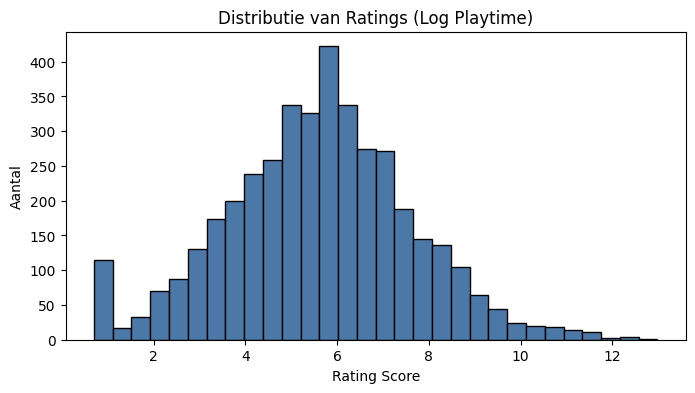

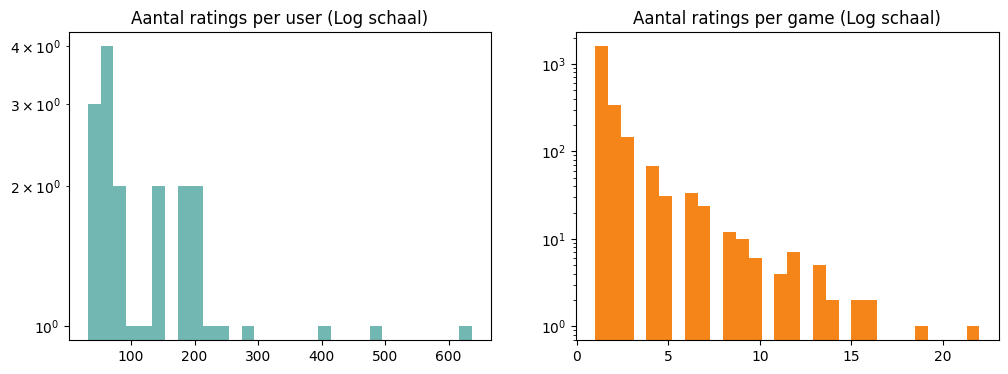

In [5]:
print("\n--- EDA ---")
print(ratings[["rating", "playtime_forever"]].describe())

# Visualisatie 1: Rating distributie
plt.figure(figsize=(8, 4))
plt.hist(ratings["rating"], bins=30, color="#4C78A8", edgecolor='black')
plt.title("Distributie van Ratings (Log Playtime)")
plt.xlabel("Rating Score")
plt.ylabel("Aantal")
plt.show()

# Visualisatie 2: Long-tail check
user_counts = ratings["user_id"].value_counts()
item_counts = ratings["app_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_counts, bins=30, log=True, color="#72B7B2")
axes[0].set_title("Aantal ratings per user (Log schaal)")
axes[1].hist(item_counts, bins=30, log=True, color="#F58518")
axes[1].set_title("Aantal ratings per game (Log schaal)")
plt.show()


## 5. Preprocessing & filtering

In [6]:
MIN_USER_RATINGS = 5
MIN_ITEM_RATINGS = 5

print(f"Filtering: Minimaal {MIN_USER_RATINGS} ratings per user, {MIN_ITEM_RATINGS} per item.")
filtered = ratings.copy()
filtered = filtered[filtered["user_id"].map(user_counts) >= MIN_USER_RATINGS]
filtered = filtered[filtered["app_id"].map(item_counts) >= MIN_ITEM_RATINGS]

print(f"Shape na filtering: {filtered.shape}")


Filtering: Minimaal 5 ratings per user, 5 per item.
Shape na filtering: (1091, 9)


## 6. Train/test split (user-level)

In [7]:
def user_train_test_split(df, test_size=0.2, random_state=42, time_col="review_date"):
    """
    Splitst data per user. Als er tijdsdata is, gebruiken we de laatste X% interacties
    als testdata (realistisch scenario). Anders random split.
    """
    train_rows = []
    test_rows = []
    has_time = time_col in df.columns

    for user_id, group in df.groupby("user_id"):
        # Te weinig data om te splitsen? Alles naar train.
        if len(group) < 2:
            train_rows.append(group)
            continue

        if has_time:
            g = group.copy()
            g[time_col] = pd.to_datetime(g[time_col], errors="coerce")
            g = g.sort_values(time_col)
            
            valid_dates = g[time_col].notna().sum()
            if valid_dates >= 2:
                split_idx = max(1, int(len(g) * (1 - test_size)))
                train_rows.append(g.iloc[:split_idx])
                test_rows.append(g.iloc[split_idx:])
                continue

        # Fallback: Random split
        train, test = train_test_split(group, test_size=test_size, random_state=random_state)
        train_rows.append(train)
        test_rows.append(test)

    train_df = pd.concat(train_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True) if test_rows else df.iloc[0:0]
    return train_df, test_df

train_df, test_df = user_train_test_split(filtered, test_size=0.2)
print(f"Train set: {train_df.shape}, Test set: {test_df.shape}")


Train set: (864, 9), Test set: (227, 9)


In [8]:
# Pivot table: Rijen=Items, Kolommen=Users
# Let op: Bij miljoenen rijen is scipy.sparse.csr_matrix beter, maar voor deze schaal is pivot prima.
item_user_matrix = train_df.pivot_table(
    index="app_id", columns="user_id", values="rating", fill_value=0
)

print("KNN Model fitten...")
model_knn = NearestNeighbors(metric="cosine", algorithm="brute", n_jobs=-1)
model_knn.fit(item_user_matrix)


KNN Model fitten...


NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1)

## 7. Recommender: Item-based Collaborative Filtering (cosine)

In [9]:
def recommend_items(user_id, knn_model, matrix, train_data, top_k=5, seed_k=3, neighbor_k=20, seasonal_index=None, seasonal_weight=0.0):
    if user_id not in matrix.columns:
        return [] # Cold start user

    # 1. Haal items op die de user al heeft (Seed items)
    user_history = train_data[train_data["user_id"] == user_id]
    
    # Sorteer op rating (hoogste eerst) en pak de top seed_k
    seeds = user_history.sort_values("rating", ascending=False).head(seed_k)["app_id"].tolist()
    owned_items = set(user_history["app_id"].tolist())

    scores = {}

    # 2. Zoek buren voor elk seed item
    for item_id in seeds:
        if item_id not in matrix.index:
            continue
        
        # Zoek nearest neighbors van dit item
        item_vec = matrix.loc[[item_id]]
        distances, indices = knn_model.kneighbors(item_vec, n_neighbors=neighbor_k)
        
        # 3. Score aggregatie
        for dist, idx in zip(distances.flatten(), indices.flatten()):
            neighbor_id = matrix.index[idx]
            
            # Sla over als user het al heeft of als het het item zelf is
            if neighbor_id in owned_items or neighbor_id == item_id:
                continue
            
            # Similarity score (1 - cosine distance)
            similarity = 1.0 - dist
            scores[neighbor_id] = scores.get(neighbor_id, 0) + similarity

    # 4. (Optioneel) seizoensboost toepassen
    if seasonal_index:
        for item_id in list(scores.keys()):
            season_factor = seasonal_index.get(item_id, 1.0)
            scores[item_id] = scores[item_id] * (1 + seasonal_weight * (season_factor - 1))

    # 5. Sorteren en top-k teruggeven
    ranked_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [item for item, score in ranked_items[:top_k]]

# Helper voor pretty printen
def _pretty(item_ids):
    return [f"{i}: {id_to_name.get(i, 'Unknown')}" for i in item_ids]

# Testje met een user
sample_user = train_df["user_id"].iloc[0]
recs = recommend_items(sample_user, model_knn, item_user_matrix, train_df, top_k=5)
print(f"Voorbeeld aanbevelingen voor user {sample_user}:")
print(_pretty(recs))


Voorbeeld aanbevelingen voor user 76561197987819677:
["4000: Garry's Mod", '304930: Unturned', '367520: Hollow Knight', '105600: Terraria', '2567870: Chained Together']


In [10]:
debug_users = train_df['user_id'].drop_duplicates().head(3).tolist()
neighbor_grid = [5, 10, 20, 40]

def _pretty(items):
    # show both id and title if available
    out = []
    for a in items:
        title = id_to_name.get(a) if 'id_to_name' in globals() else None
        out.append(f"{a} ({title})" if title else str(a))
    return out

for u in debug_users:
    print(f"\nUser {u}")
    recs_by_n = {}
    for n in neighbor_grid:
        tmp = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=n)
        tmp.fit(item_user_matrix)
        recs = recommend_items(u, tmp, item_user_matrix, train_df, top_k=5, seed_k=3, neighbor_k=n)
        recs_by_n[n] = recs
        print(f"  n={n}: {_pretty(recs)}")

    # show overlap between smallest and largest
    a, b = set(recs_by_n[neighbor_grid[0]]), set(recs_by_n[neighbor_grid[-1]])
    jacc = len(a & b) / len(a | b) if (a | b) else 0
    print(f"  Jaccard(top-5 {neighbor_grid[0]} vs {neighbor_grid[-1]}) = {jacc:.2f}")



User 76561197987819677
  n=5: ['212910', '1977530 (One-armed cook)', '239140 (Dying Light)', '739630 (Phasmophobia)', "4000 (Garry's Mod)"]
  n=10: ['212910', '1977530 (One-armed cook)', '239140 (Dying Light)', '739630 (Phasmophobia)', "4000 (Garry's Mod)"]
  n=20: ["4000 (Garry's Mod)", '304930 (Unturned)', '367520 (Hollow Knight)', '105600 (Terraria)', '2567870 (Chained Together)']
  n=40: ['346110 (ARK: Survival Evolved)', '700330 (SCP: Secret Laboratory)', '304930 (Unturned)', '550 (Left 4 Dead 2)', '578080 (PUBG: BATTLEGROUNDS)']
  Jaccard(top-5 5 vs 40) = 0.00

User 76561198021592344
  n=5: ['578080 (PUBG: BATTLEGROUNDS)']
  n=10: ['578080 (PUBG: BATTLEGROUNDS)', '239140 (Dying Light)']
  n=20: ['578080 (PUBG: BATTLEGROUNDS)', '239140 (Dying Light)', '212910', '346110 (ARK: Survival Evolved)', '200210 (Realm of the Mad God Exalt)']
  n=40: ['578080 (PUBG: BATTLEGROUNDS)', '239140 (Dying Light)', '570 (Dota 2)', '346110 (ARK: Survival Evolved)', '431960']
  Jaccard(top-5 5 vs 40)

## 8. Evaluatie: Precision/Recall + MAE/RMSE

In [11]:
def evaluate_model(knn_model, matrix, train_data, test_data, k=5, seed_k=3, neighbor_k=20):
    hits = 0
    total_relevant = 0
    total_recommended = 0
    
    # Evalueer alleen users die in de test set zitten
    test_users = test_data["user_id"].unique()
    
    for u in test_users:
        # Ground truth: wat heeft de user in de test set gedaan?
        true_items = set(test_data[test_data["user_id"] == u]["app_id"])
        if not true_items:
            continue
            
        # Voorspelling
        recs = recommend_items(u, knn_model, matrix, train_data, top_k=k, seed_k=seed_k, neighbor_k=neighbor_k)
        
        # Berekening
        intersection = len(true_items & set(recs))
        hits += intersection
        total_relevant += len(true_items)
        total_recommended += len(recs)
        
    precision = hits / total_recommended if total_recommended > 0 else 0
    recall = hits / total_relevant if total_relevant > 0 else 0
    return precision, recall

print("--- Evaluatie Start ---")
prec, rec = evaluate_model(model_knn, item_user_matrix, train_df, test_df)
print(f"Model Performance (k=5): Precision={prec:.4f}, Recall={rec:.4f}")

# MAE/RMSE evaluatie op rating-schatting (baseline)
def baseline_rating_metrics(train_data, test_data):
    if train_data.empty or test_data.empty:
        return None, None
    global_mean = train_data["rating"].mean()
    item_means = train_data.groupby("app_id")["rating"].mean()
    preds = test_data["app_id"].map(item_means).fillna(global_mean)
    mae = mean_absolute_error(test_data["rating"], preds)
    rmse = root_mean_squared_error(test_data["rating"], preds)
    return mae, rmse

mae, rmse = baseline_rating_metrics(train_df, test_df)
if mae is not None:
    print(f"Baseline Rating Metrics: MAE={mae:.4f}, RMSE={rmse:.4f}")


--- Evaluatie Start ---
Model Performance (k=5): Precision=0.1565, Recall=0.0793
Baseline Rating Metrics: MAE=1.3419, RMSE=1.7732


## 9. Cross-validation (user-level)

In [12]:
def cross_validate_knn(df, n_splits=3, k=5, neighbor_k=20, seed_k=3):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rows = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df), 1):
        train_fold = df.iloc[train_idx]
        test_fold = df.iloc[test_idx]

        fold_matrix = train_fold.pivot_table(index="app_id", columns="user_id", values="rating", fill_value=0)
        
        # FIX: Controleer hoeveel games (samples) er in de matrix zitten
        n_samples_in_fold = fold_matrix.shape[0]
        # Gebruik de kleinste waarde: de gewenste neighbor_k of het aantal beschikbare games
        actual_neighbors = min(neighbor_k, n_samples_in_fold)
        
        if actual_neighbors < 1:
            continue

        # Gebruik actual_neighbors voor de initialisatie
        fold_model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=actual_neighbors, n_jobs=-1)
        fold_model.fit(fold_matrix)

        # Geef ook actual_neighbors door aan de evaluatie
        p, r = evaluate_model(fold_model, fold_matrix, train_fold, test_fold, k=k, seed_k=seed_k, neighbor_k=actual_neighbors)
        rows.append({"fold": fold, "precision": p, "recall": r})

    return pd.DataFrame(rows)

# De aanroep werkt nu omdat neighbor_k in de definitie staat
print("\n--- Cross-validation ---")
cv_results = cross_validate_knn(filtered, n_splits=3, k=20, neighbor_k=125)
if not cv_results.empty:
    print(cv_results)
    print("\nGemiddelde resultaten:")
    print(cv_results.mean(numeric_only=True))



--- Cross-validation ---
   fold  precision    recall
0     1   0.213043  0.269231
1     2   0.228261  0.288462
2     3   0.230435  0.292011

Gemiddelde resultaten:
fold         2.000000
precision    0.223913
recall       0.283234
dtype: float64


## 10. Hyperparameter optimalisatie


--- Hyperparameter Tuning ---
   n_neighbors  precision    recall
2           50   0.226087  0.114537
1           20   0.156522  0.079295
0           10   0.149533  0.070485


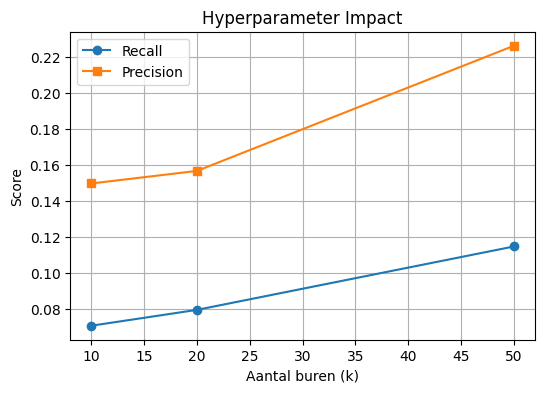

In [13]:
print("\n--- Hyperparameter Tuning ---")
neighbor_grid = [10, 20, 50]
results = []

for n in neighbor_grid:
    # Train nieuw model met n neighbors
    tmp_model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=n, n_jobs=-1)
    tmp_model.fit(item_user_matrix)
    
    p, r = evaluate_model(tmp_model, item_user_matrix, train_df, test_df, neighbor_k=n)
    results.append({"n_neighbors": n, "precision": p, "recall": r})

results_df = pd.DataFrame(results)
print(results_df.sort_values("recall", ascending=False))

# Plot resultaten
plt.figure(figsize=(6, 4))
plt.plot(results_df["n_neighbors"], results_df["recall"], marker='o', label="Recall")
plt.plot(results_df["n_neighbors"], results_df["precision"], marker='s', label="Precision")
plt.xlabel("Aantal buren (k)")
plt.ylabel("Score")
plt.title("Hyperparameter Impact")
plt.legend()
plt.grid(True)
plt.show()


## 11. Forecasting: game-level trends (release jaar)


--- Forecasting Analysis (Game-level) ---
Jaren met releases: 29


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


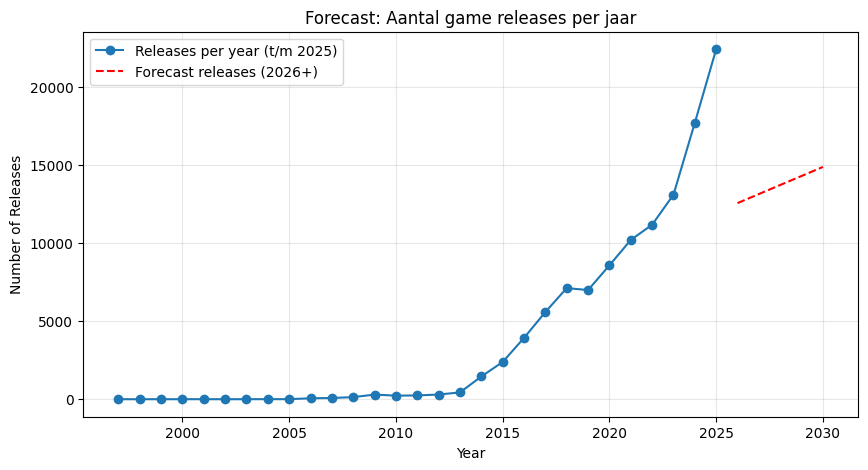

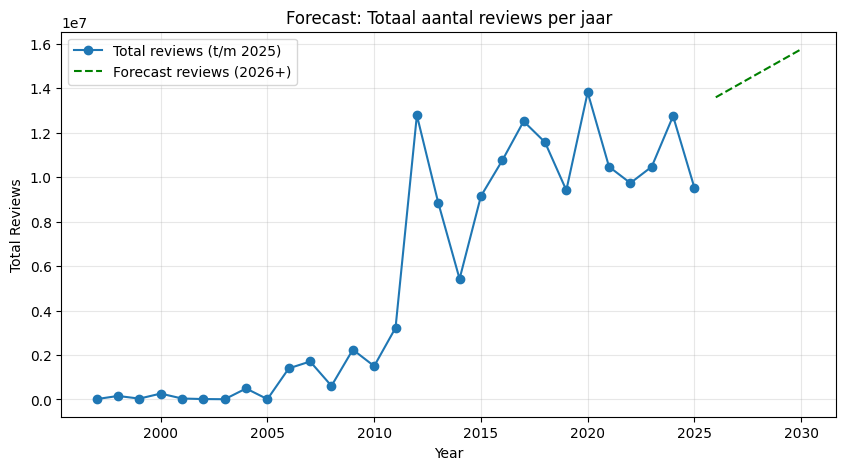

Backtest MAE (releases/year): 8867.85


In [14]:
print("\n--- Forecasting Analysis (Game-level) ---")

if "games" in globals() and not games.empty and "release_date" in games.columns:
    release_df = games.dropna(subset=["release_date"]).copy()
    if release_df.empty:
        print("Geen geldige release dates beschikbaar.")
    else:
        # Filter on realistische jaartallen (1990 t/m 2025)
        release_df["release_year"] = release_df["release_date"].dt.year
        release_df = release_df[release_df["release_year"].between(1990, 2025)]

        # Maak review volume numeriek (handig om te forecasten)
        if "ReviewTotal" in release_df.columns:
            release_df["review_total"] = pd.to_numeric(release_df["ReviewTotal"], errors="coerce").fillna(0)
        else:
            release_df["review_total"] = 0

        # Aggregatie per jaar: aantal releases + totaal reviews
        yearly = release_df.groupby("release_year").agg(
            releases=("AppId", "count"),
            total_reviews=("review_total", "sum")
        ).reset_index()

        print(f"Jaren met releases: {len(yearly)}")

        if len(yearly) >= 5:
            yearly["time_idx"] = np.arange(len(yearly))

            # Forecast aantal releases
            reg_releases = LinearRegression()
            reg_releases.fit(yearly[["time_idx"]], yearly["releases"])

            # Forecast totaal reviews (proxy voor interesse/impact)
            reg_reviews = LinearRegression()
            reg_reviews.fit(yearly[["time_idx"]], yearly["total_reviews"])

            # Forecast toekomst (start na 2025)
            forecast_horizon = 5
            future_idx = np.arange(len(yearly), len(yearly) + forecast_horizon)
            future_years = np.arange(2026, 2026 + forecast_horizon)

            future_releases = np.maximum(reg_releases.predict(future_idx.reshape(-1, 1)), 0)
            future_reviews = np.maximum(reg_reviews.predict(future_idx.reshape(-1, 1)), 0)

            # Plot: aantal releases
            plt.figure(figsize=(10, 5))
            plt.plot(yearly["release_year"], yearly["releases"], label="Releases per year (t/m 2025)", marker='o')
            plt.plot(future_years, future_releases, label="Forecast releases (2026+)", linestyle='--', color='red')
            plt.title("Forecast: Aantal game releases per jaar")
            plt.xlabel("Year")
            plt.ylabel("Number of Releases")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

            # Plot: totaal reviews
            plt.figure(figsize=(10, 5))
            plt.plot(yearly["release_year"], yearly["total_reviews"], label="Total reviews (t/m 2025)", marker='o')
            plt.plot(future_years, future_reviews, label="Forecast reviews (2026+)", linestyle='--', color='green')
            plt.title("Forecast: Totaal aantal reviews per jaar")
            plt.xlabel("Year")
            plt.ylabel("Total Reviews")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

            # Optioneel: eenvoudige MAE via backtest (laatste 20%)
            split_idx = int(len(yearly) * 0.8)
            train_y = yearly.iloc[:split_idx]
            test_y = yearly.iloc[split_idx:]

            reg_bt = LinearRegression()
            reg_bt.fit(train_y[["time_idx"]], train_y["releases"])
            bt_preds = np.maximum(reg_bt.predict(test_y[["time_idx"]]), 0)
            mae = mean_absolute_error(test_y["releases"], bt_preds)
            print(f"Backtest MAE (releases/year): {mae:.2f}")
        else:
            print("Te weinig data voor jaarlijkse forecasting.")
else:
    print("Geen game release data beschikbaar. Voeg ReleaseYear toe aan de games-collectie.")
